# Chunk 40 — Test MSE per grid, and whether 45×45 is really easier

**Question 1.** What are the **test** MSE, MAE, R² and AUROC of the fine-tuned GNN (`backbone_no55`) on 35×35 and 45×45? Until now only validation numbers existed: 1.33 and 1.10 dB². The 25×25-trained GNN (`best_model`) is also reported, on all three grids.

**Question 2.** Is the lower 45×45 error real, and is it the model or the antennas? The notebook answers this in three ways:
- **Significance:** an unpaired bootstrap of the 45×45 − 35×35 difference.
- **Model-free difficulty:** the error of always predicting each grid's average training curve, and the model's skill relative to it.
- **Depth composition:** the share of antennas in each depth bin, the error within each bin, and the 45×45 error re-weighted to the 35×35 depth mix.

**Protocol:**
- val and test sets identical to Chunk 35's
- a VAL harness that must reproduce Chunk 35's predictions and Chunk 30's gated val MSEs
- one test touch
- grids 25, 35 and 45 only
- no training

**Writes:** only `ch40_*` files.

## 1. Installs

In [1]:
!pip -q install torch_geometric pyarrow tabulate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.6 MB/s eta 0:00:00


## 2. Repository and Drive
Clones or pulls the repo and mounts Drive. Writes nothing.

In [2]:
import os, sys, subprocess
REPO_ROOT = '/content/antenna_gnn'
if os.path.isdir(f'{REPO_ROOT}/.git'):
    subprocess.run(['git', '-C', REPO_ROOT, 'pull', '-q'], check=True)
else:
    subprocess.run(['git', 'clone', '-q', 'https://github.com/asparagusD/antenna_gnn.git', REPO_ROOT], check=True)
sys.path.insert(0, f'{REPO_ROOT}/src')
from google.colab import drive
drive.mount('/content/drive')
DATA_ROOT = '/content/drive/MyDrive/antenna_gnn'
ART, CKPT, LOCAL = f'{DATA_ROOT}/artifacts', f'{DATA_ROOT}/checkpoints', '/content/local_graphs'
os.makedirs(LOCAL, exist_ok=True)
print(REPO_ROOT, DATA_ROOT)

Mounted at /content/drive
/content/antenna_gnn /content/drive/MyDrive/antenna_gnn


## 3. Setup
**What it does:**
- Hashes every input file on first read, and captures the mtimes of earlier artifacts.
- Turns TF32 off.
- Loads the s11 statistics read-only.

In [3]:
# ── Setup: scope, provenance, determinism ──
import json, glob, hashlib, zipfile, shutil, time
from pathlib import Path
import numpy as np, pandas as pd, torch
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from model import AntennaGNN
from feed_component import AppendFeedComponentFeature

GRIDS = (25, 35, 45); TAU = -10.0; F = np.linspace(1, 4, 201)
DEPTH_BINS = [(-np.inf, -30, 'deep'), (-30, -20, 'mid'), (-20, -15, 'shallow'), (-15, -10, 'marginal'), (-10, np.inf, 'nonfunc')]
torch.backends.cuda.matmul.allow_tf32 = False; torch.backends.cudnn.allow_tf32 = False
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu'); assert DEVICE.type == 'cuda', 'GPU required'

def sha(p):
    h = hashlib.sha256()
    with open(p, 'rb') as f:
        for b in iter(lambda: f.read(1 << 20), b''):
            h.update(b)
    return h.hexdigest()
READ_SHA = {}
def READ(p):
    assert os.path.exists(p), f'missing {p}'
    READ_SHA.setdefault(p, sha(p)); return p
def OUT(n):
    assert n.startswith('ch40_'), n; return f'{ART}/{n}'
PRIOR = {p: os.path.getmtime(p) for pat in (f'{ART}/ch2[89]_*', f'{ART}/ch3[0-9]_*', f'{CKPT}/*.pt')
         for p in glob.glob(pat) if os.path.isfile(p)}
TEST_TOUCHES = 0
MEAN = torch.tensor(np.load(READ(f'{ART}/s11_mean.npy')), dtype=torch.float32, device=DEVICE)   # read only
STD = torch.tensor(np.load(READ(f'{ART}/s11_std.npy')), dtype=torch.float32, device=DEVICE)
print(f'captured mtimes of {len(PRIOR)} earlier artifacts/checkpoints')

captured mtimes of 112 earlier artifacts/checkpoints


## 4. Splits
25×25 train/val/test come from `indices.json`; 35/45 pool/val/test from the fine-tune files. The val and test sets are asserted equal to Chunk 35's evaluation sets.

In [4]:
# ── Splits (grid 55 removed), reconciled with Chunk 35 ──
def pairs(v):
    if isinstance(v, dict):
        return {(int(g), int(i)) for g, x in v.items() for i in x}
    return {(int(e[0]), int(e[1])) for e in v}
IDX = json.load(open(READ(f'{DATA_ROOT}/splits/indices.json')))
FT = {r: pairs(json.load(open(READ(f'{DATA_ROOT}/splits/finetune_{r}_indices.json')))) for r in ('pool', 'val', 'test')}
SPL = {25: {'train': sorted(i for g, i in pairs(IDX['train']) if g == 25),
            'val': sorted(i for g, i in pairs(IDX['val']) if g == 25),
            'test': sorted(i for g, i in pairs(IDX['test']) if g == 25)}}
for N in (35, 45):
    SPL[N] = {'train': sorted(i for g, i in FT['pool'] if g == N), 'val': sorted(i for g, i in FT['val'] if g == N),
              'test': sorted(i for g, i in FT['test'] if g == N)}
p35 = pd.read_parquet(READ(f'{ART}/ch35_per_sample.parquet'))
for N in GRIDS:
    a, b, c = (set(SPL[N][r]) for r in ('train', 'val', 'test'))
    assert not (a & b or a & c or b & c), f'{N}: split overlap'
    for role in ('val', 'test'):
        ref = sorted(p35[(p35.model_id == 'best_model') & (p35.role == role.upper()) & (p35.grid == N)].local_idx.astype(int))
        assert ref == SPL[N][role], f'STOP: {N}x{N} {role} differs from Chunk 35'
    print(f'{N}x{N}: train/pool {len(SPL[N]["train"]):,} | val {len(SPL[N]["val"]):,} | test {len(SPL[N]["test"]):,}')
print('val and test sets equal Chunk 35\'s evaluation sets')

25x25: train/pool 79,866 | val 9,984 | test 9,983
35x35: train/pool 3,990 | val 499 | test 499
45x45: train/pool 5,587 | val 698 | test 699
val and test sets equal Chunk 35's evaluation sets


## 5. Stage graphs; mean training curves
Unzips the processed graphs and checks the node count, the virtual node and raw-dB `y`. It then computes each grid's **average training curve**, used for the model-free baseline:
- **25×25:** a seeded random 20,000 of the training antennas.
- **35/45:** the whole fine-tune pool.

Test curves are not used here.

In [5]:
# ── Stage graphs and load curves ──
def stage(N):
    d = f'{LOCAL}/{N}x{N}'
    if os.path.exists(f'{d}/_STAGED.txt'):
        return d
    os.makedirs(d, exist_ok=True)
    with zipfile.ZipFile(READ(f'{DATA_ROOT}/data/processed/processed_{N}x{N}.zip')) as Z:
        mem = [m for m in Z.namelist() if m.endswith('.pt')]
        for m in tqdm(mem, desc=f'stage {N}x{N}'):
            with Z.open(m) as a, open(f'{d}/{os.path.basename(m)}', 'wb') as b:
                shutil.copyfileobj(a, b)
    open(f'{d}/_STAGED.txt', 'w').write(str(len(mem)))
    return d
def load(N, i):
    d = torch.load(f'{LOCAL}/{N}x{N}/sample_{int(i)}.pt', weights_only=False)
    assert d.x.shape[0] == N * N + 1 and float(d.x[-1, 3]) == -1.0 and d.y.numel() == 201 and float(d.y.max()) <= 0.01
    return d
for N in GRIDS:
    stage(N)

# Mean training curve per grid, for the model-free "predict the average curve" baseline.
# 25x25: a seeded random 20,000 of the 79,866 training antennas (the mean is stable at that size);
# 35/45: the whole fine-tune pool. Test curves are never used here.
MEAN_CURVE = {}
rng = np.random.default_rng(40)
for N in GRIDS:
    ids = SPL[N]['train'] if N != 25 else sorted(rng.choice(SPL[N]['train'], 20000, replace=False).tolist())
    Y = np.stack([load(N, i).y.reshape(-1).numpy() for i in tqdm(ids, desc=f'train curves {N}x{N}', leave=False)]).astype(np.float64)
    MEAN_CURVE[N] = Y.mean(0)
    print(f'{N}x{N}: mean training curve from {len(ids):,} antennas')

stage 25x25:   0%|          | 0/99833 [00:00<?, ?it/s]

stage 35x35:   0%|          | 0/4988 [00:00<?, ?it/s]

stage 45x45:   0%|          | 0/6984 [00:00<?, ?it/s]

train curves 25x25:   0%|          | 0/20000 [00:00<?, ?it/s]

25x25: mean training curve from 20,000 antennas


train curves 35x35:   0%|          | 0/3990 [00:00<?, ?it/s]

35x35: mean training curve from 3,990 antennas


train curves 45x45:   0%|          | 0/5587 [00:00<?, ?it/s]

45x45: mean training curve from 5,587 antennas


## 6. Models
**What it does:**
- Loads `best_model` (5 inputs, 587,001 parameters) and `backbone_no55` (6 inputs with the feed-component feature, 587,129 parameters) strictly.
- Asserts the backbone file is the checkpoint Chunk 30 gated.
- Defines `predict()`, which returns the true curves and both models' predicted curves in raw dB.

In [6]:
# ── Models ──
def gnn(nf):
    return AntennaGNN(node_feat_dim=nf, edge_feat_dim=2, hidden_dim=128, heads=8, edge_dim=16, num_blocks=4, output_dim=201)
def state_of(path):
    c = torch.load(READ(path), map_location='cpu', weights_only=False)
    s = c['model_state'] if isinstance(c, dict) and 'model_state' in c else c
    return {k[7:] if k.startswith('module.') else k: v for k, v in s.items()}
MODELS = {}
m = gnn(5); m.load_state_dict(state_of(f'{CKPT}/best_model.pt'), strict=True); MODELS['best_model'] = (m.to(DEVICE).eval(), 5)
m = gnn(6); m.load_state_dict(state_of(f'{CKPT}/backbone_no55.pt'), strict=True); MODELS['backbone_no55'] = (m.to(DEVICE).eval(), 6)
assert sum(p.numel() for p in MODELS['best_model'][0].parameters()) == 587_001
assert sum(p.numel() for p in MODELS['backbone_no55'][0].parameters()) == 587_129
REP30 = json.load(open(READ(f'{ART}/ch30_backbone_report.json')))
assert sha(f'{CKPT}/backbone_no55.pt') == REP30['checkpoint_sha'], 'STOP: backbone_no55.pt is not the gated Chunk 30 checkpoint'
TRANSFORM = AppendFeedComponentFeature()

@torch.no_grad()
def predict(N, ids, bs=64):
    """True curves and both models' predicted curves (raw dB) for the given graphs."""
    T, P = [], {k: [] for k in MODELS}
    for s in tqdm(range(0, len(ids), bs), desc=f'{N}x{N}', leave=False):
        ds = [load(N, i) for i in ids[s:s + bs]]
        T.append(np.stack([d.y.reshape(-1).numpy() for d in ds]))
        for name, (m, nf) in MODELS.items():
            gs = [Data(x=d.x, edge_index=d.edge_index, edge_attr=d.edge_attr) for d in ds] if nf == 5 else \
                 [TRANSFORM(Data(x=d.x.clone(), edge_index=d.edge_index, edge_attr=d.edge_attr)) for d in ds]
            b = next(iter(DataLoader(gs, batch_size=len(gs)))).to(DEVICE)
            P[name].append((m(b) * STD + MEAN).double().cpu().numpy())
    return np.concatenate(T).astype(np.float64), {k: np.concatenate(v) for k, v in P.items()}
print('models loaded; backbone_no55 is the gated Chunk 30 checkpoint')

models loaded; backbone_no55 is the gated Chunk 30 checkpoint


## 7. VAL harness (before test)
**What it checks:**
- Both models' val minima reproduce Chunk 35 to within 1e-3 dB on ≥ 99.9% of antennas.
- `backbone_no55`'s val MSE per grid reproduces Chunk 30's gate report to within 0.01 dB².

Otherwise the cell stops.

In [7]:
# ── VAL harness (before any test access) ──
VAL = {N: predict(N, SPL[N]['val']) for N in GRIDS}
for N in GRIDS:
    T, P = VAL[N]
    for name in MODELS:
        ref = p35[(p35.model_id == name) & (p35.role == 'VAL') & (p35.grid == N)].sort_values('local_idx').pred_min_db.to_numpy()
        d = np.abs(P[name].min(1) - ref)
        print(f'{N}x{N} {name:14s} VAL minima vs Chunk 35: within 1e-3 dB {(d < 1e-3).mean():.4%} (max {d.max():.1e})')
        assert (d < 1e-3).mean() >= .999, f'STOP: {name} {N}x{N} does not reproduce Chunk 35'
# backbone_no55 VAL MSE must reproduce Chunk 30's gate numbers
ref30 = {r['scope']: r.get('replay_mse', r.get('backbone_no55_mse')) for r in REP30.get('per_scope', [])}
for N in GRIDS:
    T, P = VAL[N]; v = float(((P['backbone_no55'] - T) ** 2).mean()); r = ref30.get(f'grid_{N}_VAL')
    print(f'{N}x{N} backbone_no55 VAL MSE {v:.4f} | Chunk 30 report {r if r is None else round(r, 4)}')
    if r is not None:
        assert abs(v - r) < 0.01, f'STOP: VAL MSE {v:.4f} differs from Chunk 30 report {r:.4f}'
HARNESS = True; print('VAL harness passed; TEST untouched')

25x25:   0%|          | 0/156 [00:00<?, ?it/s]

35x35:   0%|          | 0/8 [00:00<?, ?it/s]

45x45:   0%|          | 0/11 [00:00<?, ?it/s]

25x25 best_model     VAL minima vs Chunk 35: within 1e-3 dB 100.0000% (max 6.5e-05)
25x25 backbone_no55  VAL minima vs Chunk 35: within 1e-3 dB 100.0000% (max 7.2e-05)
35x35 best_model     VAL minima vs Chunk 35: within 1e-3 dB 100.0000% (max 4.2e-05)
35x35 backbone_no55  VAL minima vs Chunk 35: within 1e-3 dB 100.0000% (max 2.1e-05)
45x45 best_model     VAL minima vs Chunk 35: within 1e-3 dB 100.0000% (max 5.7e-05)
45x45 backbone_no55  VAL minima vs Chunk 35: within 1e-3 dB 100.0000% (max 2.9e-05)
25x25 backbone_no55 VAL MSE 1.3692 | Chunk 30 report 1.3692
35x35 backbone_no55 VAL MSE 1.3277 | Chunk 30 report 1.3277
45x45 backbone_no55 VAL MSE 1.0966 | Chunk 30 report 1.0966
VAL harness passed; TEST untouched


## 8. TEST TOUCH
The only cell that scores test graphs, guarded by a counter. It re-checks the test minima against Chunk 35.

**Writes:** `ch40_per_sample.parquet`.

In [8]:
# ── TEST TOUCH (the only cell that scores test graphs) ──
assert globals().get('HARNESS') is True and TEST_TOUCHES == 0; TEST_TOUCHES += 1
TEST = {N: predict(N, SPL[N]['test']) for N in GRIDS}
rows = []
for N in GRIDS:
    T, P = TEST[N]
    for name in MODELS:
        Pm = P[name]
        for k, li in enumerate(SPL[N]['test']):
            rows.append(dict(model_id=name, grid=N, local_idx=li, true_min_db=T[k].min(), pred_min_db=Pm[k].min(),
                             mse_db2=((Pm[k] - T[k]) ** 2).mean(), mae_db=np.abs(Pm[k] - T[k]).mean(),
                             true_argmin_ghz=F[T[k].argmin()], pred_argmin_ghz=F[Pm[k].argmin()]))
    for name in MODELS:   # test minima must also reproduce Chunk 35
        ref = p35[(p35.model_id == name) & (p35.role == 'TEST') & (p35.grid == N)].sort_values('local_idx').pred_min_db.to_numpy()
        assert (np.abs(P[name].min(1) - ref) < 1e-3).mean() >= .999, f'STOP: {name} {N}x{N} test minima differ from Chunk 35'
PER = pd.DataFrame(rows); PER.to_parquet(OUT('ch40_per_sample.parquet'), index=False)
print(f'TEST touched once: {len(PER):,} rows written to ch40_per_sample.parquet')

25x25:   0%|          | 0/156 [00:00<?, ?it/s]

35x35:   0%|          | 0/8 [00:00<?, ?it/s]

45x45:   0%|          | 0/11 [00:00<?, ?it/s]

TEST touched once: 22,362 rows written to ch40_per_sample.parquet


## 9. Metrics
**Per model and grid:** MSE, RMSE, MAE, pooled R², AUROC and resonant-frequency MAE, with 95% stratified bootstrap intervals (1,000 resamples, rng 401). Equal-grid means are given over 35/45 and over all three grids.

**Writes:** `ch40_metrics.csv`.

In [10]:
# ── Metrics with 95% bootstrap intervals ──
R = 1000
def dbin(v):
    return next(l for lo, hi, l in DEPTH_BINS if lo < v <= hi) if v <= -10 else 'nonfunc'

def grid_stats(name, N, rng):
    T, P = TEST[N]; Pm = P[name]
    mse = ((Pm - T) ** 2).mean(1); mae = np.abs(Pm - T).mean(1)
    y = (T.min(1) < TAU).astype(int); s = -Pm.min(1)
    ferr = np.abs(F[T.argmin(1)] - F[Pm.argmin(1)])
    sst_i = ((T - T.mean()) ** 2).sum(1); sse_i = ((Pm - T) ** 2).sum(1)
    pt = dict(mse_db2=mse.mean(), rmse_db=np.sqrt(mse.mean()), mae_db=mae.mean(), r2=1 - sse_i.sum() / sst_i.sum(),
              auroc=roc_auc_score(y, s), res_freq_mae_ghz=ferr[y == 1].mean())
    i0, i1 = np.flatnonzero(y == 0), np.flatnonzero(y == 1)
    reps = {k: np.empty(R) for k in ('mse_db2', 'mae_db', 'r2', 'auroc')}
    for r in tqdm(range(R), desc=f'{name} {N}x{N} bootstrap', leave=False):
        ii = np.r_[rng.choice(i0, len(i0)), rng.choice(i1, len(i1))]
        reps['mse_db2'][r] = mse[ii].mean(); reps['mae_db'][r] = mae[ii].mean()
        reps['r2'][r] = 1 - sse_i[ii].sum() / ((T[ii] - T[ii].mean()) ** 2).sum()
        reps['auroc'][r] = roc_auc_score(y[ii], s[ii])
    return pt, reps, dict(mse=mse, mae=mae, y=y)

PT, REPS, PERS = {}, {}, {}
for name in MODELS:
    for N in GRIDS:
        PT[(name, N)], REPS[(name, N)], PERS[(name, N)] = grid_stats(name, N, np.random.default_rng(401))

rows = []
for name in MODELS:
    scopes = [(f'grid_{N}', [N]) for N in GRIDS] + [('EQUAL_GRID_35_45', [35, 45]), ('EQUAL_GRID_25_35_45', list(GRIDS))]
    for scope, gs in scopes:
        for k in PT[(name, gs[0])]:
            est = float(np.mean([PT[(name, N)][k] for N in gs]))
            if k in REPS[(name, gs[0])]:
                rep = np.mean([REPS[(name, N)][k] for N in gs], axis=0); lo, hi = np.quantile(rep, [.025, .975])
            else:
                lo = hi = np.nan
            rows.append(dict(model_id=name, scope=scope, metric=k, estimate=est, lo=lo, hi=hi, n=sum(len(SPL[N]['test']) for N in gs)))

MET = pd.DataFrame(rows); MET.to_csv(OUT('ch40_metrics.csv'), index=False)
show = MET[MET.metric.isin(['mse_db2', 'mae_db', 'r2', 'auroc'])].copy()
show['value'] = [f'{e:.4f} [{l:.4f}, {h:.4f}]' if not np.isnan(l) else f'{e:.4f}' for e, l, h in zip(show.estimate, show.lo, show.hi)]
pd.set_option('display.width', 250)
print(show.pivot_table(index=['scope', 'model_id'], columns='metric', values='value', aggfunc='first').to_string())

best_model 25x25 bootstrap:   0%|          | 0/1000 [00:00<?, ?it/s]

best_model 35x35 bootstrap:   0%|          | 0/1000 [00:00<?, ?it/s]

best_model 45x45 bootstrap:   0%|          | 0/1000 [00:00<?, ?it/s]

backbone_no55 25x25 bootstrap:   0%|          | 0/1000 [00:00<?, ?it/s]

backbone_no55 35x35 bootstrap:   0%|          | 0/1000 [00:00<?, ?it/s]

backbone_no55 45x45 bootstrap:   0%|          | 0/1000 [00:00<?, ?it/s]

metric                                               auroc                   mae_db                  mse_db2                       r2
scope               model_id                                                                                                         
EQUAL_GRID_25_35_45 backbone_no55  0.9327 [0.9242, 0.9402]  0.3430 [0.3329, 0.3531]  1.2110 [1.1457, 1.2830]  0.8218 [0.8099, 0.8325]
                    best_model     0.9240 [0.9142, 0.9333]  0.5448 [0.5366, 0.5543]  2.5125 [2.4356, 2.5951]  0.6055 [0.5927, 0.6175]
EQUAL_GRID_35_45    backbone_no55  0.9464 [0.9336, 0.9577]  0.3207 [0.3059, 0.3359]  1.1279 [1.0298, 1.2346]  0.8150 [0.7977, 0.8314]
                    best_model     0.9340 [0.9194, 0.9474]  0.6302 [0.6188, 0.6436]  3.1099 [2.9973, 3.2328]  0.4870 [0.4681, 0.5044]
grid_25             backbone_no55  0.9052 [0.8993, 0.9108]  0.3876 [0.3821, 0.3926]  1.3774 [1.3412, 1.4131]  0.8353 [0.8303, 0.8405]
                    best_model     0.9040 [0.8979, 0.9096]  0.

## 10. Comparisons
**(a) Fine-tuned against zero-shot**, paired on the same test antennas per grid.

**(b) 45×45 − 35×35 for the fine-tuned GNN.** These are different antennas, so the bootstrap is unpaired. A verdict states whether 45×45 is significantly lower.

**Writes:** `ch40_comparisons.csv`.

In [11]:
# ── Comparisons: fine-tuned vs zero-shot, and 35x35 vs 45x45 ──
cmp_rows = []
# (a) paired backbone_no55 - best_model on the same test graphs, per grid
for N in GRIDS:
    a, b = PERS[('backbone_no55', N)], PERS[('best_model', N)]; y = a['y']
    i0, i1 = np.flatnonzero(y == 0), np.flatnonzero(y == 1); rng = np.random.default_rng(402)
    for k in ('mse', 'mae'):
        d = a[k] - b[k]; reps = np.array([d[np.r_[rng.choice(i0, len(i0)), rng.choice(i1, len(i1))]].mean() for _ in range(R)])
        lo, hi = np.quantile(reps, [.025, .975])
        cmp_rows.append(dict(comparison=f'backbone_no55 - best_model (paired), {N}x{N}', metric=k, estimate=d.mean(), lo=lo, hi=hi,
                             verdict='fine-tuned better' if hi < 0 else ('zero-shot better' if lo > 0 else 'no significant difference')))
# (b) 45x45 - 35x35 for backbone_no55: different antennas, so an UNPAIRED bootstrap of the difference
rng = np.random.default_rng(403)
for k in ('mse', 'mae'):
    x35, x45 = PERS[('backbone_no55', 35)][k], PERS[('backbone_no55', 45)][k]
    reps = np.array([rng.choice(x45, len(x45)).mean() - rng.choice(x35, len(x35)).mean() for _ in range(R)])
    lo, hi = np.quantile(reps, [.025, .975])
    cmp_rows.append(dict(comparison='backbone_no55: 45x45 - 35x35 (unpaired)', metric=k, estimate=x45.mean() - x35.mean(), lo=lo, hi=hi,
                         verdict='45x45 lower' if hi < 0 else ('35x35 lower' if lo > 0 else 'no significant difference')))
CMP = pd.DataFrame(cmp_rows); CMP.to_csv(OUT('ch40_comparisons.csv'), index=False)
print(CMP.round(4).to_string(index=False))

                                comparison metric  estimate      lo      hi                   verdict
backbone_no55 - best_model (paired), 25x25    mse    0.0598  0.0511  0.0699          zero-shot better
backbone_no55 - best_model (paired), 25x25    mae    0.0134  0.0119  0.0149          zero-shot better
backbone_no55 - best_model (paired), 35x35    mse   -1.3832 -1.5470 -1.2153         fine-tuned better
backbone_no55 - best_model (paired), 35x35    mae   -0.2371 -0.2569 -0.2187         fine-tuned better
backbone_no55 - best_model (paired), 45x45    mse   -2.5810 -2.7750 -2.3980         fine-tuned better
backbone_no55 - best_model (paired), 45x45    mae   -0.3818 -0.4030 -0.3607         fine-tuned better
   backbone_no55: 45x45 - 35x35 (unpaired)    mse   -0.0354 -0.2340  0.1725 no significant difference
   backbone_no55: 45x45 - 35x35 (unpaired)    mae   -0.0221 -0.0510  0.0116 no significant difference


## 11. Is one grid intrinsically easier?
**Per grid (test truths only):**
- prevalence, mean minimum, and the share of antennas below −20 and −30 dB
- per-point variance
- **baseline MSE:** always predicting that grid's average training curve
- **skill** = 1 − model MSE / baseline MSE

**Depth composition:** the share of antennas in each depth bin and the fine-tuned GNN's MSE within each bin.

**Standardisation:** the 45×45 MSE re-weighted to the 35×35 depth mix.
- If the 45×45 advantage disappears under that re-weighting, it comes from *which* antennas are in the set.
- If it persists, the model genuinely predicts 45×45 better.

**Writes:** `ch40_difficulty.csv`, `ch40_depth_bins.csv`, `ch40_standardisation.json`.

In [12]:
# ── Is one grid intrinsically easier? Model-free difficulty, skill, and depth composition ──
diff_rows, bin_rows = [], []
for N in GRIDS:
    T = TEST[N][0]; mins = T.min(1)
    base = ((T - MEAN_CURVE[N]) ** 2).mean(1)            # "always predict the average training curve of this grid"
    rec = dict(grid=N, n_test=len(T), prevalence=float((mins < TAU).mean()), mean_min_db=float(mins.mean()),
               share_below_20db=float((mins < -20).mean()), share_below_30db=float((mins < -30).mean()),
               per_point_variance_db2=float(T.var(0).mean()), baseline_mse_db2=float(base.mean()))
    for name in MODELS:
        rec[f'{name}_mse_db2'] = float(PERS[(name, N)]['mse'].mean())
        rec[f'{name}_skill'] = 1 - rec[f'{name}_mse_db2'] / rec['baseline_mse_db2']
    diff_rows.append(rec)
    bins = np.array([dbin(v) for v in mins])
    for _, _, l in DEPTH_BINS:
        m = bins == l
        bin_rows.append(dict(grid=N, depth_bin=l, share=float(m.mean()), n=int(m.sum()),
                             backbone_mse_db2=float(PERS[('backbone_no55', N)]['mse'][m].mean()) if m.any() else np.nan))
DIFF = pd.DataFrame(diff_rows); BINS = pd.DataFrame(bin_rows)
DIFF.to_csv(OUT('ch40_difficulty.csv'), index=False); BINS.to_csv(OUT('ch40_depth_bins.csv'), index=False)
print(DIFF.round(4).T.to_string())
print('\n' + BINS.pivot(index='depth_bin', columns='grid', values=['share', 'backbone_mse_db2']).round(4).to_string())

# Standardisation: 45x45 per-bin MSE re-weighted to the 35x35 depth mix (and vice versa). If the 45x45 advantage
# disappears under 35x35 weights, it comes from WHICH antennas are in the set, not from better prediction.
def std_mse(src, weights_from):
    w = BINS[BINS.grid == weights_from].set_index('depth_bin').share
    m = BINS[BINS.grid == src].set_index('depth_bin').backbone_mse_db2
    ok = m.notna() & (w > 0)
    return float((m[ok] * w[ok]).sum() / w[ok].sum())
STDZ = dict(mse35_raw=DIFF.set_index('grid').loc[35, 'backbone_no55_mse_db2'], mse45_raw=DIFF.set_index('grid').loc[45, 'backbone_no55_mse_db2'],
           mse45_with_35_mix=std_mse(45, 35), mse35_with_45_mix=std_mse(35, 45))
gap_raw = STDZ['mse35_raw'] - STDZ['mse45_raw']; gap_std = STDZ['mse35_raw'] - STDZ['mse45_with_35_mix']
STDZ['gap_raw'] = gap_raw; STDZ['gap_at_same_depth_mix'] = gap_std
STDZ['share_of_gap_from_composition'] = (gap_raw - gap_std) / gap_raw if abs(gap_raw) > 1e-9 else np.nan
print('\nDepth-mix standardisation (backbone_no55):', {k: round(v, 4) for k, v in STDZ.items()})
json.dump({k: float(v) for k, v in STDZ.items()}, open(OUT('ch40_standardisation.json'), 'w'), indent=2)

                                0         1         2
grid                      25.0000   35.0000   45.0000
n_test                  9983.0000  499.0000  699.0000
prevalence                 0.5705    0.6373    0.6552
mean_min_db              -13.4695  -12.1983  -11.6290
share_below_20db           0.2613    0.1363    0.1159
share_below_30db           0.0713    0.0120    0.0243
per_point_variance_db2     5.7549    4.1238    3.9605
baseline_mse_db2           5.7553    4.1489    3.9655
best_model_mse_db2         1.3175    2.5287    3.6912
best_model_skill           0.7711    0.3905    0.0692
backbone_no55_mse_db2      1.3774    1.1456    1.1102
backbone_no55_skill        0.7607    0.7239    0.7200

            share                 backbone_mse_db2                
grid           25      35      45               25      35      45
depth_bin                                                         
deep       0.0713  0.0120  0.0243           2.0418  2.4634  5.0307
marginal   0.1664  0.3086  0.

## 12. Figure and report
**Figure, three panels:**
- (a) test MSE per grid with intervals, for both models
- (b) depth composition per grid
- (c) the fine-tuned GNN's error within each depth bin

**Report:** tables and a short reading. The composition explanation is only interpreted if the 35-vs-45 gap is significant.

**Writes:** `ch40_test_mse.png`, `ch40_report.md`.

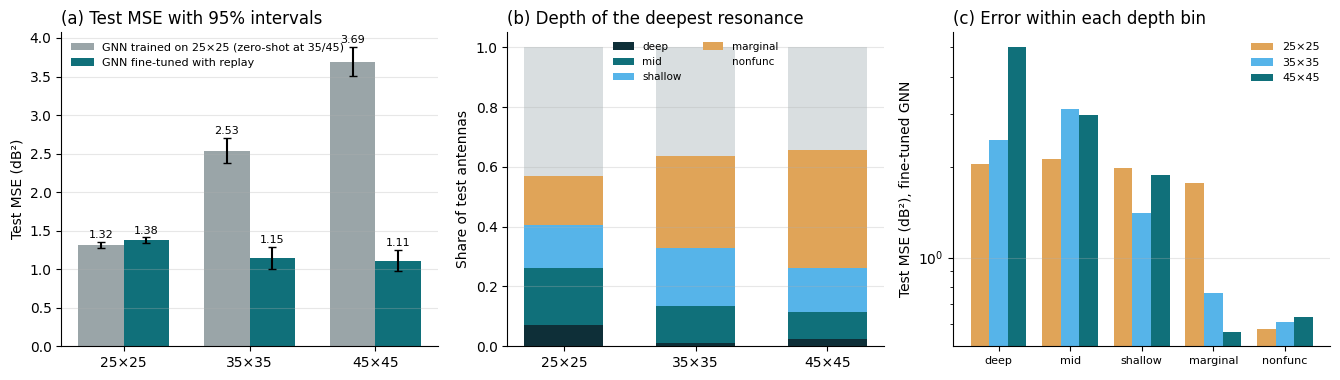

# Chunk 40 — Test MSE per grid (25×25, 35×35, 45×45)

One test touch; 95% stratified bootstrap intervals (1,000 resamples). `best_model` is trained on 25×25 only (zero-shot at 35/45); `backbone_no55` is fine-tuned on the 35/45 pool with 25×25 replay (Chunk 30 v2).

| scope | model | MSE (dB²) | MAE (dB) | R² | AUROC |
|---|---|---|---|---|---|
| grid_25 | best_model | 1.318 [1.281, 1.352] | 0.374 [0.369, 0.379] | 0.842 [0.837, 0.847] | 0.904 [0.898, 0.910] |
| grid_25 | backbone_no55 | 1.377 [1.341, 1.413] | 0.388 [0.382, 0.393] | 0.835 [0.830, 0.841] | 0.905 [0.899, 0.911] |
| grid_35 | best_model | 2.529 [2.378, 2.699] | 0.569 [0.552, 0.588] | 0.597 [0.567, 0.623] | 0.929 [0.905, 0.952] |
| grid_35 | backbone_no55 | 1.146 [1.004, 1.290] | 0.332 [0.311, 0.356] | 0.818 [0.793, 0.841] | 0.943 [0.924, 0.960] |
| grid_45 | best_model | 3.691 [3.509, 3.879] | 0.692 [0.673, 0.710] | 0.377 [0.354, 0.400] | 0.939 [0.922, 0.955] |
| grid_45 | backbone_no55 | 1.110 [0.976, 1.246] | 0.310 [0.288

In [13]:
# ── Figure and report ──
fig, ax = plt.subplots(1, 3, figsize=(13.5, 3.9))
x = np.arange(3); w = 0.36
for j, (name, col, lab) in enumerate((('best_model', '#9AA5A8', 'GNN trained on 25×25 (zero-shot at 35/45)'),
                                       ('backbone_no55', '#10707A', 'GNN fine-tuned with replay'))):
    e = [PT[(name, N)]['mse_db2'] for N in GRIDS]
    lo = [e[i] - np.quantile(REPS[(name, N)]['mse_db2'], .025) for i, N in enumerate(GRIDS)]
    hi = [np.quantile(REPS[(name, N)]['mse_db2'], .975) - e[i] for i, N in enumerate(GRIDS)]
    ax[0].bar(x + (j - .5) * w, e, w, yerr=[lo, hi], color=col, capsize=3, label=lab)
    for i, v in enumerate(e): ax[0].text(x[i] + (j - .5) * w, v + hi[i] + 0.05, f'{v:.2f}', ha='center', fontsize=8)
ax[0].set_xticks(x); ax[0].set_xticklabels([f'{N}×{N}' for N in GRIDS]); ax[0].set_ylabel('Test MSE (dB²)')
ax[0].set_title('(a) Test MSE with 95% intervals', loc='left'); ax[0].legend(frameon=False, fontsize=8)
cols = {'deep': '#0E2F38', 'mid': '#10707A', 'shallow': '#56B4E9', 'marginal': '#E0A458', 'nonfunc': '#D9DEE0'}
bottom = np.zeros(3)
for _, _, l in DEPTH_BINS:
    s = [BINS[(BINS.grid == N) & (BINS.depth_bin == l)].share.iloc[0] for N in GRIDS]
    ax[1].bar(x, s, 0.6, bottom=bottom, color=cols[l], label=l); bottom += s
ax[1].set_xticks(x); ax[1].set_xticklabels([f'{N}×{N}' for N in GRIDS]); ax[1].set_ylabel('Share of test antennas')
ax[1].set_title('(b) Depth of the deepest resonance', loc='left'); ax[1].legend(frameon=False, fontsize=7.5, ncol=2)
labs = [l for _, _, l in DEPTH_BINS]; xb = np.arange(len(labs)); wb = 0.26
for j, N in enumerate(GRIDS):
    v = [BINS[(BINS.grid == N) & (BINS.depth_bin == l)].backbone_mse_db2.iloc[0] for l in labs]
    ax[2].bar(xb + (j - 1) * wb, v, wb, label=f'{N}×{N}', color=('#E0A458', '#56B4E9', '#10707A')[j])
ax[2].set_xticks(xb); ax[2].set_xticklabels(labs, fontsize=8); ax[2].set_yscale('log'); ax[2].set_ylabel('Test MSE (dB²), fine-tuned GNN')
ax[2].set_title('(c) Error within each depth bin', loc='left'); ax[2].legend(frameon=False, fontsize=8)
for a in ax: a.grid(alpha=.3, axis='y'); a.spines[['top', 'right']].set_visible(False)
fig.tight_layout(); fig.savefig(OUT('ch40_test_mse.png'), dpi=200); plt.show()

def cell(name, scope, k):
    r = MET[(MET.model_id == name) & (MET.scope == scope) & (MET.metric == k)].iloc[0]
    return f'{r.estimate:.3f} [{r.lo:.3f}, {r.hi:.3f}]' if not np.isnan(r.lo) else f'{r.estimate:.3f}'
L = ['# Chunk 40 — Test MSE per grid (25×25, 35×35, 45×45)', '',
     'One test touch; 95% stratified bootstrap intervals (1,000 resamples). `best_model` is trained on 25×25 only '
     '(zero-shot at 35/45); `backbone_no55` is fine-tuned on the 35/45 pool with 25×25 replay (Chunk 30 v2).', '',
     '| scope | model | MSE (dB²) | MAE (dB) | R² | AUROC |', '|---|---|---|---|---|---|']
for scope in ['grid_25', 'grid_35', 'grid_45', 'EQUAL_GRID_35_45', 'EQUAL_GRID_25_35_45']:
    for name in MODELS:
        L.append(f'| {scope} | {name} | {cell(name, scope, "mse_db2")} | {cell(name, scope, "mae_db")} | {cell(name, scope, "r2")} | {cell(name, scope, "auroc")} |')
L += ['', '## Comparisons', CMP.round(4).to_markdown(index=False), '',
      '## Is one grid intrinsically easier?',
      'Baseline = MSE of always predicting that grid\'s average training curve (model-free). Skill = 1 − model MSE / baseline MSE.', '',
      DIFF.round(4).to_markdown(index=False), '', '### Depth composition and per-bin error (fine-tuned GNN)',
      BINS.pivot(index='depth_bin', columns='grid', values=['share', 'backbone_mse_db2']).round(4).to_markdown(), '',
      '### Depth-mix standardisation', '```', json.dumps({k: round(float(v), 4) for k, v in STDZ.items()}, indent=2), '```', '',
      '## Reading']
c45 = CMP[(CMP.comparison.str.startswith('backbone_no55: 45x45')) & (CMP.metric == 'mse')].iloc[0]
L.append(f'- 45×45 − 35×35 test MSE for the fine-tuned GNN: {c45.estimate:+.3f} dB² [{c45.lo:+.3f}, {c45.hi:+.3f}] → **{c45.verdict}**.')
if c45.verdict != 'no significant difference':
    L.append(f'- Re-weighting 45×45 to the 35×35 depth mix changes its MSE from {STDZ["mse45_raw"]:.3f} to {STDZ["mse45_with_35_mix"]:.3f} dB²; '
             f'the share of the 35-vs-45 gap explained by depth composition is {STDZ["share_of_gap_from_composition"]:.0%}.')
else:
    L.append('- The 35-vs-45 gap is not significant on test, so there is no gap for depth composition to explain; the '
             'standardised values are reported for completeness only.')
L.append(f'- Skill relative to the average-curve baseline: ' + ', '.join(f'{r.grid}×{r.grid} {r.backbone_no55_skill:.3f}' for r in DIFF.itertuples())
         + '. Where skill is similar but raw MSE differs, the grids differ in how variable their curves are rather than in how well '
         'the model predicts; where skill differs, the model genuinely predicts one grid better.')
open(OUT('ch40_report.md'), 'w').write('\n'.join(L) + '\n'); print('\n'.join(L))

## 13. Guards
**What it checks:**
- one test touch
- grids 25/35/45 only
- every test antenna scored by both models
- inputs unchanged
- earlier artifacts unmodified
- outputs named `ch40_*`

In [14]:
# ── Guards ──
fails = []
def guard(ok, msg):
    print(f"  [{'PASS' if ok else 'FAIL'}] {msg}")
    if not ok: fails.append(msg)
guard(TEST_TOUCHES == 1, 'TEST touched exactly once')
guard(set(PER.grid) == set(GRIDS) and not (PER.grid == 55).any(), 'grids 25/35/45 only')
guard(all(len(PER[(PER.model_id == m) & (PER.grid == N)]) == len(SPL[N]['test']) for m in MODELS for N in GRIDS), 'every test antenna scored by both models')
guard(all(sha(p) == h for p, h in READ_SHA.items()), f'input files unchanged ({len(READ_SHA)})')
guard(all(os.path.getmtime(p) == t for p, t in PRIOR.items() if os.path.exists(p)), f'no earlier artifact modified ({len(PRIOR)})')
guard(all(Path(p).name.startswith('ch40_') for p in glob.glob(f'{ART}/ch40_*')), 'all outputs ch40_*')
assert not fails, fails
print('ALL GUARDS PASSED. No training occurred.')

  [PASS] TEST touched exactly once
  [PASS] grids 25/35/45 only
  [PASS] every test antenna scored by both models
  [PASS] input files unchanged (13)
  [PASS] no earlier artifact modified (112)
  [PASS] all outputs ch40_*
ALL GUARDS PASSED. No training occurred.
